# EndoScan AI — MRI Branch (From Extracted PNGs)
> **Assumes `mri_slice_records.json` and PNG slices already exist.**
> Starts directly from DataLoader → Train → Evaluate.

| Phase | Cell |
|---|---|
| Imports & Config | 1–2 |
| Load & inspect records | 3 |
| Patient split + class balance | 4 |
| Dataset & DataLoaders | 5–6 |
| Build model | 7 |
| Train | 8 |
| Training curves | 9 |
| Test evaluation | 10 |
| Evaluation plots | 11 |
| Grad-CAM | 12 |
| Save checkpoint | 13 |

---
## Cell 1 — Imports

In [2]:
import json, copy, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import rotate, zoom as scipy_zoom

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix
)
import timm

print('All imports OK')
print(f'PyTorch : {torch.__version__}')
print(f'timm    : {timm.__version__}')
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Device  : {device_name}')

All imports OK
PyTorch : 2.13.0+cu130
timm    : 1.0.29
Device  : CPU


---
## Cell 2 — Config

In [3]:
# ── Paths — update these to match your actual output folder ──────────
PNG_DIR         = Path('./outputs/mri_slices')
RECORDS_PATH    = Path('./outputs/mri_slice_records.json')
CHECKPOINT_PATH = Path('./outputs/mri_best_model.pt')
RESULTS_DIR     = Path('./outputs')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 50
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 8
FREEZE_BLOCKS = 6
DROPOUT       = 0.3
SEED          = 42
NUM_WORKERS   = 0    # set to 2-4 on Linux/Colab for speed

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Sanity checks ────────────────────────────────────────────────────
assert RECORDS_PATH.exists(), \
    f'Records not found at {RECORDS_PATH} — run the extraction notebook first.'
assert PNG_DIR.exists() and any(PNG_DIR.glob('*.png')), \
    f'No PNGs found in {PNG_DIR} — run the extraction notebook first.'

n_pngs = len(list(PNG_DIR.glob('*.png')))
print(f'Device       : {DEVICE}')
print(f'Records      : {RECORDS_PATH}  ✓')
print(f'PNG dir      : {PNG_DIR}  ({n_pngs:,} files)  ✓')
print(f'Hyperparams  : IMG={IMG_SIZE} | BS={BATCH_SIZE} | LR={LR} | '
      f'EP={EPOCHS} | patience={PATIENCE} | freeze={FREEZE_BLOCKS} blocks')

Device       : cpu
Records      : outputs/mri_slice_records.json  ✓
PNG dir      : outputs/mri_slices  (4,242 files)  ✓
Hyperparams  : IMG=224 | BS=32 | LR=0.0001 | EP=50 | patience=8 | freeze=6 blocks


---
## Cell 3 — Load & inspect records

In [4]:
with open(RECORDS_PATH) as f:
    all_records = json.load(f)

n_total = len(all_records)
n_pos   = sum(r['label'] == 1 for r in all_records)
n_neg   = n_total - n_pos
n_pts   = len(set(r['patient_id'] for r in all_records))
institutions = set(r['institution'] for r in all_records)

print(f'Loaded {n_total:,} slice records')
print(f'  Patients     : {n_pts}')
print(f'  Institutions : {institutions}')
print(f'  Positive     : {n_pos:,}  ({n_pos/n_total*100:.1f}%)')
print(f'  Negative     : {n_neg:,}  ({n_neg/n_total*100:.1f}%)')
print(f'  Imbalance    : 1 : {n_neg // max(n_pos, 1)}')
print(f'\nSample record:')
print(json.dumps(all_records[0], indent=2))

# ── Verify a handful of PNGs are actually on disk ────────────────────
missing = 0
for rec in random.sample(all_records, min(200, n_total)):
    fname = (f"{rec['patient_id']}_sl{rec['slice_idx']:03d}"
             f"_label{rec['label']}.png")
    if not (PNG_DIR / fname).exists():
        missing += 1
if missing == 0:
    print('\nSpot-check: all sampled PNGs found on disk  ✓')
else:
    print(f'\n⚠  {missing} sampled PNGs missing from {PNG_DIR}')

Loaded 4,242 slice records
  Patients     : 92
  Institutions : {'D1_MHS', 'D2_TCPW'}
  Positive     : 352  (8.3%)
  Negative     : 3,890  (91.7%)
  Imbalance    : 1 : 11

Sample record:
{
  "patient_id": "D1-000",
  "institution": "D1_MHS",
  "slice_idx": 0,
  "label": 0,
  "t2_path": "/home/joy/Downloads/UT-EndoMRI/D1_MHS/D1-000/D1-000_T2.nii",
  "is_d1": true
}

Spot-check: all sampled PNGs found on disk  ✓


---
## Cell 4 — Patient-level split + class balance

Patient-level split (no leakage verified):
  Train:  64 patients |  2,838 slices |   252 pos (8.9%)
  Val  :  13 patients |    645 slices |    44 pos (6.8%)
  Test :  15 patients |    759 slices |    56 pos (7.4%)


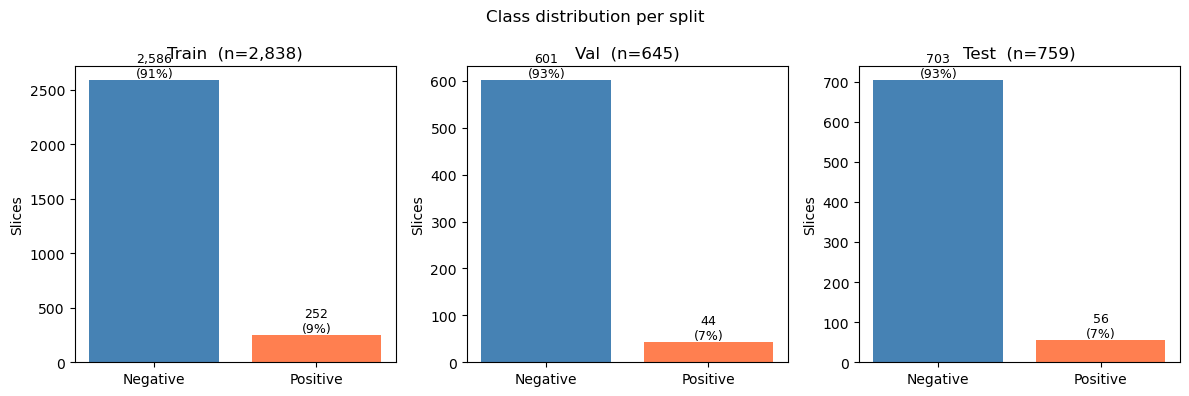

Saved -> outputs/class_distribution.png


In [5]:
# Split by patient — never by slice — to prevent data leakage.

all_ids = list(set(r['patient_id'] for r in all_records))
rng = random.Random(SEED)
rng.shuffle(all_ids)

n_train   = int(len(all_ids) * 0.70)
n_val     = int(len(all_ids) * 0.15)
train_ids = set(all_ids[:n_train])
val_ids   = set(all_ids[n_train:n_train + n_val])
test_ids  = set(all_ids[n_train + n_val:])

assert train_ids.isdisjoint(val_ids),  'LEAK: train/val overlap!'
assert train_ids.isdisjoint(test_ids), 'LEAK: train/test overlap!'
assert val_ids.isdisjoint(test_ids),   'LEAK: val/test overlap!'

train_records = [r for r in all_records if r['patient_id'] in train_ids]
val_records   = [r for r in all_records if r['patient_id'] in val_ids]
test_records  = [r for r in all_records if r['patient_id'] in test_ids]

print('Patient-level split (no leakage verified):')
for name, recs in [('Train', train_records),
                   ('Val',   val_records),
                   ('Test',  test_records)]:
    n   = len(recs)
    pos = sum(r['label'] == 1 for r in recs)
    pts = len(set(r['patient_id'] for r in recs))
    print(f'  {name:5s}: {pts:3d} patients | {n:6,} slices | '
          f'{pos:5,} pos ({pos/n*100:.1f}%)')

# ── Class distribution plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, recs) in zip(axes, [('Train', train_records),
                                    ('Val',   val_records),
                                    ('Test',  test_records)]):
    n     = len(recs)
    n_p   = sum(r['label'] == 1 for r in recs)
    n_n   = n - n_p
    bars  = ax.bar(['Negative', 'Positive'], [n_n, n_p],
                   color=['steelblue', 'coral'])
    ax.set_title(f'{name}  (n={n:,})')
    ax.set_ylabel('Slices')
    for bar, v in zip(bars, [n_n, n_p]):
        ax.text(bar.get_x() + bar.get_width()/2, v + n*0.01,
                f'{v:,}\n({v/n*100:.0f}%)', ha='center', fontsize=9)
plt.suptitle('Class distribution per split', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/class_distribution.png')

---
## Cell 5 — Dataset

In [6]:
def augment_slice(sl: np.ndarray) -> np.ndarray:
    """Geometry-only augmentation — MRI intensities are clinically meaningful."""
    if np.random.rand() > 0.5: sl = np.fliplr(sl)
    if np.random.rand() > 0.3: sl = np.flipud(sl)
    if np.random.rand() > 0.5:
        sl = rotate(sl, np.random.uniform(-15, 15), reshape=False, order=1)
    if np.random.rand() > 0.5:
        f      = np.random.uniform(0.9, 1.1)
        z      = scipy_zoom(sl, f, order=1)
        h, w   = sl.shape
        zh, zw = z.shape
        if f > 1.0:
            sl = z[(zh-h)//2:(zh-h)//2+h, (zw-w)//2:(zw-w)//2+w]
        else:
            ph, pw = (h-zh)//2, (w-zw)//2
            sl = np.pad(z, ((ph, h-zh-ph), (pw, w-zw-pw)), mode='constant')
    return sl.astype(np.float32)


class MRISliceDataset(Dataset):
    """
    Loads pre-saved PNGs.  Filename format:
        {patient_id}_sl{slice_idx:03d}_label{label}.png
    """
    def __init__(self, records, png_dir, augment=False, img_size=IMG_SIZE):
        self.records  = records
        self.png_dir  = Path(png_dir)
        self.augment  = augment
        self.img_size = img_size

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec   = self.records[idx]
        fname = (f"{rec['patient_id']}_"
                 f"sl{rec['slice_idx']:03d}_"
                 f"label{rec['label']}.png")
        sl = np.array(
            Image.open(self.png_dir / fname).convert('L'),
            dtype=np.float32)
        sl = sl / 255.0 * 2.0 - 1.0          # [0,255] → [-1,1]

        if self.augment:
            sl = augment_slice(sl)

        if sl.shape[0] != self.img_size or sl.shape[1] != self.img_size:
            sl = scipy_zoom(sl,
                            (self.img_size / sl.shape[0],
                             self.img_size / sl.shape[1]), order=1)

        sl_3ch = np.stack([sl, sl, sl], axis=0)    # greyscale → 3-channel
        return (torch.tensor(sl_3ch, dtype=torch.float32),
                torch.tensor(rec['label'], dtype=torch.float32))


# ── Smoke test ───────────────────────────────────────────────────────
ds_smoke = MRISliceDataset(train_records[:4], PNG_DIR, augment=False)
img, lbl = ds_smoke[0]
print(f'Dataset defined OK')
print(f'Sample tensor : shape={tuple(img.shape)} | '
      f'min={img.min():.2f}  max={img.max():.2f} | label={int(lbl)}')

Dataset defined OK
Sample tensor : shape=(3, 224, 224) | min=-1.00  max=0.91 | label=0


---
## Cell 6 — DataLoaders

In [7]:
train_ds = MRISliceDataset(train_records, PNG_DIR, augment=True)
val_ds   = MRISliceDataset(val_records,   PNG_DIR, augment=False)
test_ds  = MRISliceDataset(test_records,  PNG_DIR, augment=False)

# ── Weighted sampler to balance the 1:11 pos/neg imbalance ──────────
train_labels = [r['label'] for r in train_records]
n_pos_train  = sum(train_labels)
n_neg_train  = len(train_labels) - n_pos_train
pos_weight   = n_neg_train / n_pos_train   # passed to BCEWithLogitsLoss later

sample_weights = torch.tensor(
    [1.0/n_pos_train if l == 1 else 1.0/n_neg_train for l in train_labels],
    dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),
                                replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f'pos_weight (for loss) = {pos_weight:.2f}  '
      f'(n_pos={n_pos_train:,}, n_neg={n_neg_train:,})')
print(f'Train : {len(train_loader):3d} batches  |  {len(train_ds):,} samples')
print(f'Val   : {len(val_loader):3d} batches  |  {len(val_ds):,} samples')
print(f'Test  : {len(test_loader):3d} batches  |  {len(test_ds):,} samples')

# ── Quick batch shape check ──────────────────────────────────────────
imgs_b, labels_b = next(iter(train_loader))
print(f'\nBatch shape : {tuple(imgs_b.shape)}  '
      f'labels: {labels_b[:8].int().tolist()}')

pos_weight (for loss) = 10.26  (n_pos=252, n_neg=2,586)
Train :  89 batches  |  2,838 samples
Val   :  21 batches  |  645 samples
Test  :  24 batches  |  759 samples

Batch shape : (32, 3, 224, 224)  labels: [1, 1, 0, 1, 0, 1, 1, 1]


---
## Cell 7 — Build model

In [8]:
# EfficientNet-B0 pretrained on ImageNet.
# Blocks 0–5 frozen (low-level features); block 6 + head trainable (~28%).

model = timm.create_model('efficientnet_b0', pretrained=True)

# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze from block FREEZE_BLOCKS onwards
for block in model.blocks[FREEZE_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

# Unfreeze conv head and batch norm
for m in [model.conv_head, model.bn2]:
    for param in m.parameters():
        param.requires_grad = True

# Replace classifier with a single binary output
in_feat = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(in_feat, 1)
)

model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}  ({trainable/total*100:.1f}%)')
print(f'Frozen parameters    : {total-trainable:,}  ({(total-trainable)/total*100:.1f}%)')

# ── Forward pass check ───────────────────────────────────────────────
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
print(f'Forward pass OK: output shape = {tuple(out.shape)}')

Total parameters     : 4,008,829
Trainable parameters : 1,130,673  (28.2%)
Frozen parameters    : 2,878,156  (71.8%)
Forward pass OK: output shape = (2, 1)


---
## Cell 8 — Training loop

In [9]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight]).to(DEVICE))
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Early stopping state
best_val_loss  = float('inf')
patience_count = 0
best_weights   = copy.deepcopy(model.state_dict())
MIN_DELTA      = 1e-4

# History — all keys populated inside the loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_auc': [],
    'val_recall': [], 'val_precision': [],
    'val_f1'    : [], 'val_specificity': [],
}

print(f'Loss      : BCEWithLogitsLoss  pos_weight={pos_weight:.2f}')
print(f'Optimiser : Adam  lr={LR}  wd={WEIGHT_DECAY}')
print(f'Scheduler : CosineAnnealingLR  T_max={EPOCHS}')
print(f'Patience  : {PATIENCE} epochs')
print('-' * 95)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ────────────────────────────────────────────────────────
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * imgs.size(0)
        tr_correct += ((torch.sigmoid(out) > 0.5).float() == labels).sum().item()
        tr_total   += imgs.size(0)

    train_loss = tr_loss / tr_total
    train_acc  = tr_correct / tr_total * 100

    # ── Validate ─────────────────────────────────────────────────────
    model.eval()
    vl_loss = vl_correct = vl_total = 0
    val_probs_ep, val_labels_ep = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            out   = model(imgs)
            loss  = criterion(out, labels)
            probs = torch.sigmoid(out).cpu().squeeze(1)
            vl_loss    += loss.item() * imgs.size(0)
            vl_correct += ((probs > 0.5).float() ==
                           labels.cpu().squeeze(1)).sum().item()
            vl_total   += imgs.size(0)
            val_probs_ep.extend(probs.numpy())
            val_labels_ep.extend(labels.cpu().squeeze(1).numpy())

    val_loss = vl_loss / vl_total
    val_acc  = vl_correct / vl_total * 100

    vp = np.array(val_probs_ep)
    vl = np.array(val_labels_ep)
    vd = (vp > 0.5).astype(float)

    try:    val_auc = roc_auc_score(vl, vp)
    except: val_auc = float('nan')

    tp = ((vd==1)&(vl==1)).sum(); fp = ((vd==1)&(vl==0)).sum()
    fn = ((vd==0)&(vl==1)).sum(); tn = ((vd==0)&(vl==0)).sum()

    precision   = tp/(tp+fp)  if (tp+fp)>0  else float('nan')
    recall      = tp/(tp+fn)  if (tp+fn)>0  else float('nan')
    f1          = (2*precision*recall/(precision+recall)
                   if not (np.isnan(precision) or np.isnan(recall))
                   and (precision+recall)>0 else float('nan'))
    specificity = tn/(tn+fp)  if (tn+fp)>0  else float('nan')

    # ── Append all history keys ───────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_recall'].append(recall)
    history['val_precision'].append(precision)
    history['val_f1'].append(f1)
    history['val_specificity'].append(specificity)

    scheduler.step()

    # ── Checkpoint on improvement ────────────────────────────────────
    improved = val_loss < best_val_loss - MIN_DELTA
    if improved:
        best_val_loss  = val_loss
        best_weights   = copy.deepcopy(model.state_dict())
        patience_count = 0
        torch.save({'epoch': epoch,
                    'model_state_dict': best_weights,
                    'val_loss': val_loss,
                    'val_auc' : val_auc,
                    'history' : history},
                   CHECKPOINT_PATH)
    else:
        patience_count += 1

    tag = '  ← best' if improved else f'  (no improvement {patience_count}/{PATIENCE})'
    print(f'Ep {epoch:3d}/{EPOCHS} | '
          f'tr {train_loss:.4f} / {train_acc:.1f}% | '
          f'val {val_loss:.4f} / {val_acc:.1f}% | '
          f'auc {val_auc:.3f}  rec {recall:.3f}  '
          f'f1 {f1:.3f}  spec {specificity:.3f} | '
          f'{time.time()-t0:.0f}s{tag}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

# Restore best weights
model.load_state_dict(best_weights)
best_ep = history['val_loss'].index(min(history['val_loss'])) + 1
print(f'\nDone.  Best epoch: {best_ep} | '
      f'val loss: {min(history["val_loss"]):.4f} | '
      f'val AUC: {max(history["val_auc"]):.4f}')

Loss      : BCEWithLogitsLoss  pos_weight=10.26
Optimiser : Adam  lr=0.0001  wd=0.0001
Scheduler : CosineAnnealingLR  T_max=50
Patience  : 8 epochs
-----------------------------------------------------------------------------------------------
Ep   1/50 | tr 2.1266 / 55.1% | val 1.3828 / 21.1% | auc 0.882  rec 1.000  f1 0.147  spec 0.153 | 195s  ← best
Ep   2/50 | tr 1.0746 / 62.7% | val 1.3581 / 37.4% | auc 0.848  rec 0.977  f1 0.176  spec 0.329 | 176s  ← best
Ep   3/50 | tr 0.8493 / 69.3% | val 1.2338 / 48.5% | auc 0.843  rec 0.909  f1 0.194  spec 0.454 | 166s  ← best
Ep   4/50 | tr 0.6572 / 79.5% | val 0.9901 / 65.9% | auc 0.836  rec 0.795  f1 0.241  spec 0.649 | 176s  ← best
Ep   5/50 | tr 0.5470 / 84.8% | val 0.9843 / 70.7% | auc 0.841  rec 0.795  f1 0.270  spec 0.700 | 163s  ← best
Ep   6/50 | tr 0.4717 / 87.7% | val 1.0773 / 74.0% | auc 0.829  rec 0.795  f1 0.294  spec 0.735 | 146s  (no improvement 1/8)
Ep   7/50 | tr 0.3879 / 90.9% | val 1.1306 / 73.2% | auc 0.835  rec 0.795  f

---
## Cell 9 — Training curves

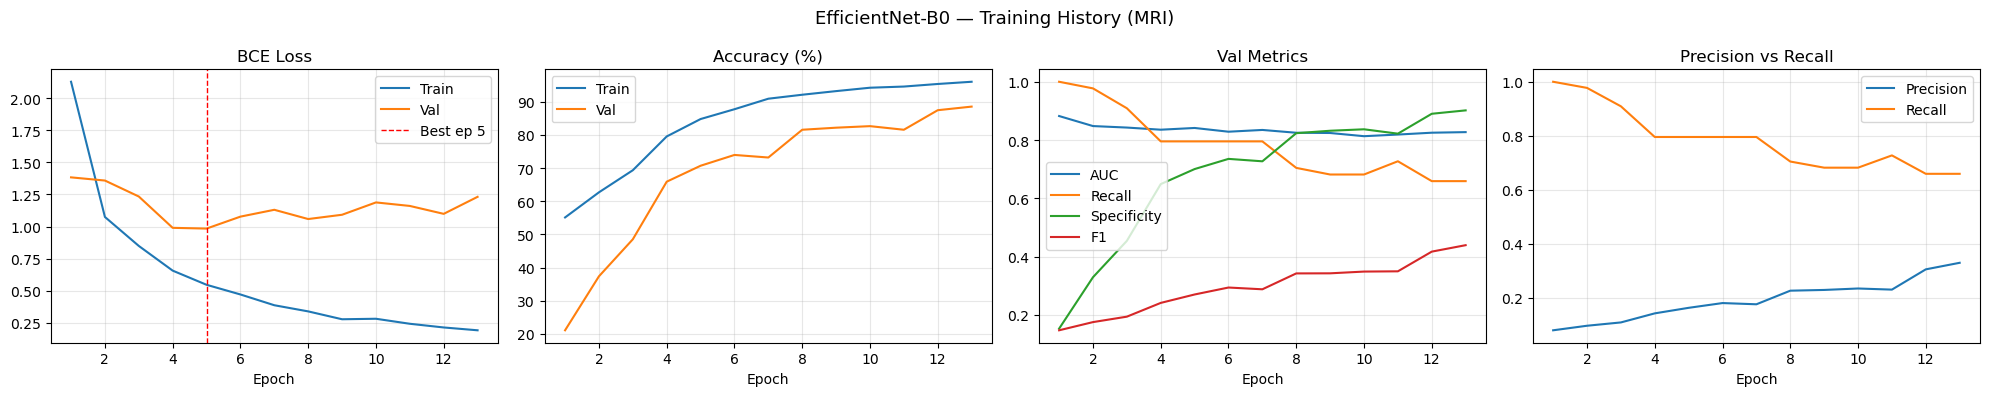

Saved -> outputs/training_curves.png


In [10]:
epochs_ran = len(history['val_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Loss
axes[0].plot(x, history['train_loss'], label='Train')
axes[0].plot(x, history['val_loss'],   label='Val')
axes[0].axvline(best_ep, color='red', linestyle='--', linewidth=1,
                label=f'Best ep {best_ep}')
axes[0].set_title('BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Epoch')

# Accuracy
axes[1].plot(x, history['train_acc'], label='Train')
axes[1].plot(x, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Epoch')

# AUC / Recall / Specificity / F1
axes[2].plot(x, history['val_auc'],         label='AUC')
axes[2].plot(x, history['val_recall'],      label='Recall')
axes[2].plot(x, history['val_specificity'], label='Specificity')
axes[2].plot(x, history['val_f1'],          label='F1')
axes[2].set_title('Val Metrics'); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Epoch')

# Precision vs Recall
axes[3].plot(x, history['val_precision'], label='Precision')
axes[3].plot(x, history['val_recall'],    label='Recall')
axes[3].set_title('Precision vs Recall'); axes[3].legend(); axes[3].grid(alpha=0.3)
axes[3].set_xlabel('Epoch')

plt.suptitle('EfficientNet-B0 — Training History (MRI)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/training_curves.png')

---
## Cell 10 — Test set evaluation

In [11]:
model.eval()
all_probs, all_labels_test = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().squeeze(1)
        all_probs.extend(probs.numpy())
        all_labels_test.extend(labels.numpy())

all_probs       = np.array(all_probs)
all_labels_test = np.array(all_labels_test)
all_preds       = (all_probs > 0.5).astype(float)

try:    test_auc = roc_auc_score(all_labels_test, all_probs)
except: test_auc = float('nan')

cm = confusion_matrix(all_labels_test, all_preds)
tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
sensitivity = tp/(tp+fn) if (tp+fn)>0 else float('nan')
specificity = tn/(tn+fp) if (tn+fp)>0 else float('nan')
accuracy    = (all_preds == all_labels_test).mean() * 100

n_test     = len(all_labels_test)
n_pos_test = int(all_labels_test.sum())

print('=' * 60)
print('  TEST SET EVALUATION — MRI (EfficientNet-B0)')
print('=' * 60)
print(f'  Samples      : {n_test} ({n_pos_test} pos / {n_test-n_pos_test} neg)')
print(f'  AUC-ROC      : {test_auc:.4f}   (target ≥ 0.85)')
print(f'  Accuracy     : {accuracy:.1f}%')
print(f'  Sensitivity  : {sensitivity:.3f}   (target ≥ 0.80)')
print(f'  Specificity  : {specificity:.3f}   (target ≥ 0.75)')
print()
try:
    print(classification_report(
        all_labels_test, all_preds,
        target_names=['No endo', 'Endo'], digits=3))
except ValueError as e:
    print(f'classification_report: {e}')
print('=' * 60)

print('\nClinical targets:')
for metric, val, thr in [('AUC-ROC',     test_auc,    0.85),
                          ('Sensitivity', sensitivity, 0.80),
                          ('Specificity', specificity, 0.75)]:
    status = '✅ MET' if val >= thr else '❌ NOT MET'
    print(f'  {metric:12s}: {val:.3f}  (≥{thr})  {status}')

  TEST SET EVALUATION — MRI (EfficientNet-B0)
  Samples      : 759 (56 pos / 703 neg)
  AUC-ROC      : 0.8364   (target ≥ 0.85)
  Accuracy     : 75.1%
  Sensitivity  : 0.839   (target ≥ 0.80)
  Specificity  : 0.744   (target ≥ 0.75)

              precision    recall  f1-score   support

     No endo      0.983     0.744     0.847       703
        Endo      0.207     0.839     0.332        56

    accuracy                          0.751       759
   macro avg      0.595     0.792     0.590       759
weighted avg      0.926     0.751     0.809       759


Clinical targets:
  AUC-ROC     : 0.836  (≥0.85)  ❌ NOT MET
  Sensitivity : 0.839  (≥0.8)  ✅ MET
  Specificity : 0.744  (≥0.75)  ❌ NOT MET


---
## Cell 11 — Evaluation plots

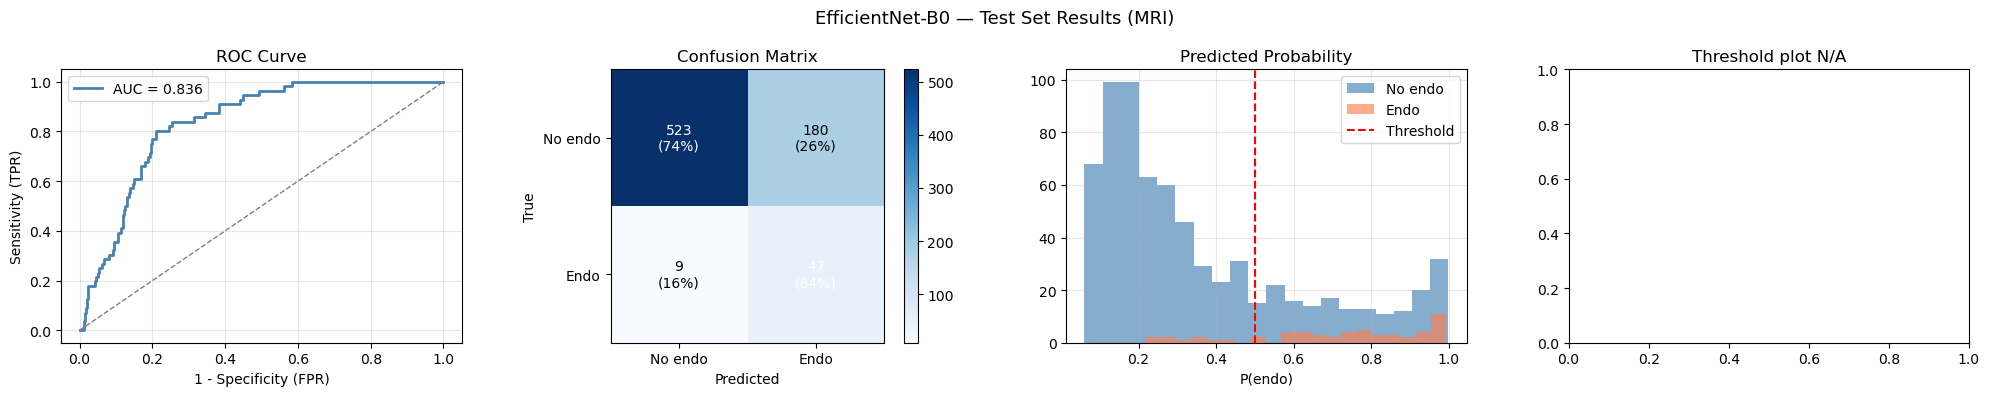

Saved -> outputs/mri_results.png


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. ROC curve
try:
    fpr, tpr, thresholds = roc_curve(all_labels_test, all_probs)
    axes[0].plot(fpr, tpr, lw=2, color='steelblue',
                 label=f'AUC = {test_auc:.3f}')
    axes[0].plot([0,1],[0,1],'--',color='gray',linewidth=1)
    axes[0].set_xlabel('1 - Specificity (FPR)')
    axes[0].set_ylabel('Sensitivity (TPR)')
    axes[0].set_title('ROC Curve')
    axes[0].legend(); axes[0].grid(alpha=0.3)
except Exception as e:
    axes[0].set_title(f'ROC error: {e}')

# 2. Confusion matrix
im = axes[1].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[1])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)',
                     ha='center', va='center',
                     color='white' if cm_norm[i,j] > 0.5 else 'black')
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['No endo','Endo'])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['No endo','Endo'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

# 3. Confidence histogram
pos_p = all_probs[all_labels_test == 1]
neg_p = all_probs[all_labels_test == 0]
axes[2].hist(neg_p, bins=20, alpha=0.65, label='No endo', color='steelblue')
axes[2].hist(pos_p, bins=20, alpha=0.65, label='Endo',    color='coral')
axes[2].axvline(0.5, color='red', linestyle='--', linewidth=1.5,
                label='Threshold')
axes[2].set_title('Predicted Probability')
axes[2].set_xlabel('P(endo)'); axes[2].legend(); axes[2].grid(alpha=0.3)

# 4. Sensitivity / Specificity vs threshold
try:
    axes[3].plot(thresholds, tpr[:-1],     label='Sensitivity', color='coral')
    axes[3].plot(thresholds, 1-fpr[:-1],   label='Specificity', color='steelblue')
    axes[3].axvline(0.5, color='gray', linestyle='--', linewidth=1)
    axes[3].set_title('Sens / Spec vs Threshold')
    axes[3].set_xlabel('Threshold')
    axes[3].legend(); axes[3].grid(alpha=0.3)
except Exception:
    axes[3].set_title('Threshold plot N/A')

plt.suptitle('EfficientNet-B0 — Test Set Results (MRI)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mri_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/mri_results.png')

---
## Cell 12 — Grad-CAM

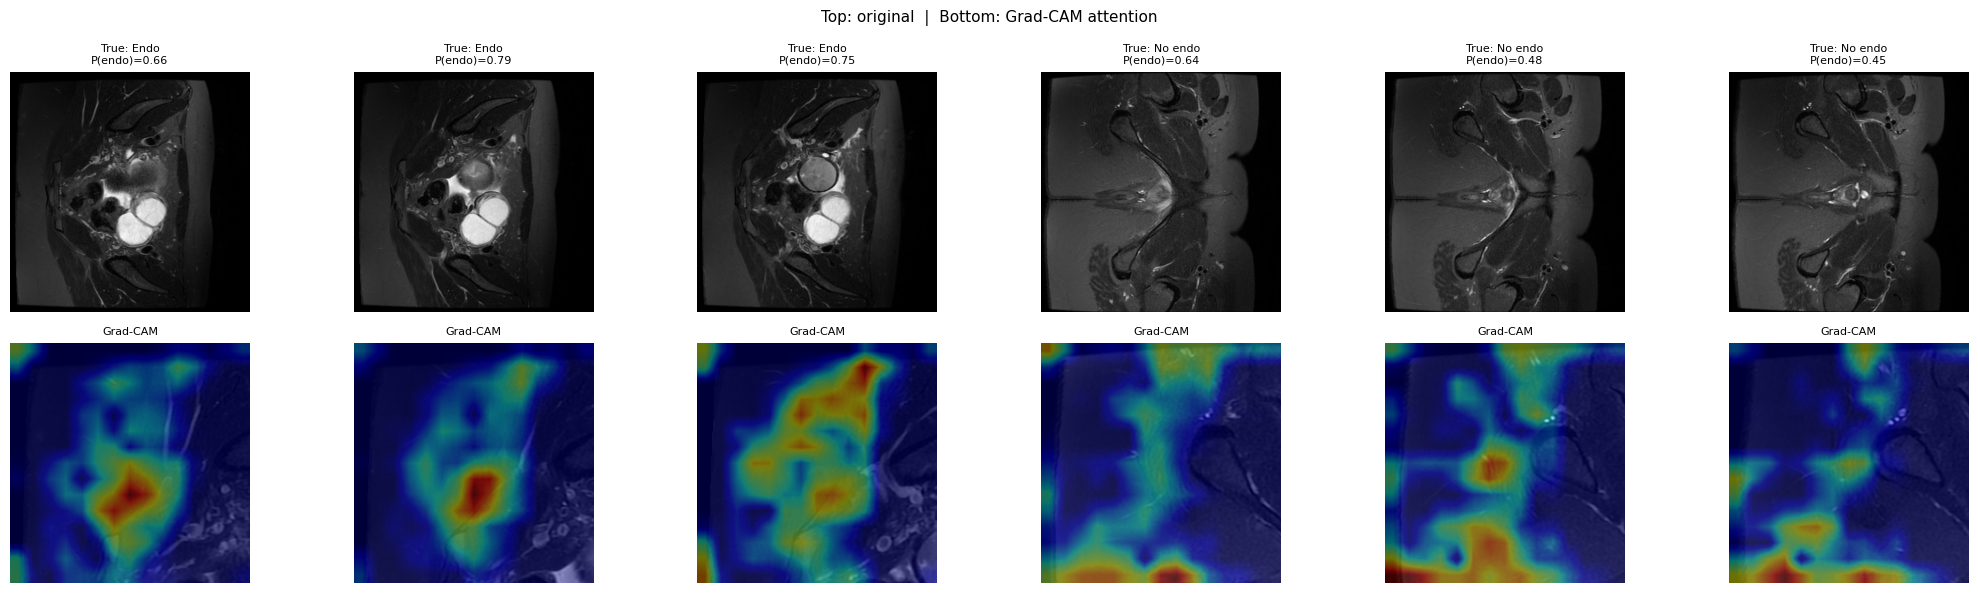

Saved -> outputs/gradcam.png


In [13]:
# Hooks onto the last conv block to visualise where the model looks.

activations, gradients = {}, {}

def fwd_hook(module, inp, out): activations['feat'] = out.detach()
def bwd_hook(module, g_in, g_out): gradients['feat'] = g_out[0].detach()

target_layer = model.blocks[-1][-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_full_backward_hook(bwd_hook)


def grad_cam(img_tensor: torch.Tensor) -> np.ndarray:
    model.eval()
    img = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    out = model(img)
    model.zero_grad()
    out.backward()
    grads   = gradients['feat'].squeeze(0)
    acts    = activations['feat'].squeeze(0)
    weights = grads.mean(dim=(1,2), keepdim=True)
    cam     = (weights * acts).sum(dim=0).cpu().numpy()
    cam     = np.maximum(cam, 0)
    if cam.max() > 0: cam /= cam.max()
    cam = np.array(
        Image.fromarray((cam*255).astype(np.uint8))
             .resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0
    return cam


pos_recs = [r for r in test_records if r['label'] == 1][:3]
neg_recs = [r for r in test_records if r['label'] == 0][:3]
samples  = pos_recs + neg_recs

fig, axes = plt.subplots(2, len(samples), figsize=(3.5*len(samples), 6))

for col, rec in enumerate(samples):
    fname = (f"{rec['patient_id']}_sl{rec['slice_idx']:03d}"
             f"_label{rec['label']}.png")
    png_p = PNG_DIR / fname
    if not png_p.exists(): continue

    raw  = np.array(Image.open(png_p).convert('L'), dtype=np.float32)
    sl   = raw / 255.0 * 2.0 - 1.0
    tens = torch.tensor(np.stack([sl,sl,sl],0), dtype=torch.float32)
    cam  = grad_cam(tens)

    with torch.no_grad():
        prob = torch.sigmoid(
            model(tens.unsqueeze(0).to(DEVICE))).item()

    title = f'True: {"Endo" if rec["label"]==1 else "No endo"}\nP(endo)={prob:.2f}'
    axes[0,col].imshow(raw/255., cmap='gray')
    axes[0,col].set_title(title, fontsize=8); axes[0,col].axis('off')
    axes[1,col].imshow(raw/255., cmap='gray')
    axes[1,col].imshow(cam, cmap='jet', alpha=0.45)
    axes[1,col].set_title('Grad-CAM', fontsize=8); axes[1,col].axis('off')

plt.suptitle('Top: original  |  Bottom: Grad-CAM attention', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

h1.remove(); h2.remove()
print('Saved -> outputs/gradcam.png')

---
## Cell 13 — Save final checkpoint

In [14]:
torch.save({
    'model_state_dict': model.state_dict(),
    'history'         : history,
    'train_patients'  : list(set(r['patient_id'] for r in train_records)),
    'val_patients'    : list(set(r['patient_id'] for r in val_records)),
    'test_patients'   : list(set(r['patient_id'] for r in test_records)),
    'metrics': {
        'auc'        : float(test_auc),
        'accuracy'   : float(accuracy),
        'sensitivity': float(sensitivity),
        'specificity': float(specificity),
    },
    'config': {
        'img_size'     : IMG_SIZE,
        'batch_size'   : BATCH_SIZE,
        'epochs_run'   : len(history['val_loss']),
        'best_epoch'   : best_ep,
        'lr'           : LR,
        'freeze_blocks': FREEZE_BLOCKS,
        'dropout'      : DROPOUT,
        'modality'     : 'MRI',
        'model'        : 'efficientnet_b0',
    }
}, CHECKPOINT_PATH)

print(f'Checkpoint saved  -> {CHECKPOINT_PATH}')
print(f'AUC-ROC           : {test_auc:.4f}')
print(f'Sensitivity       : {sensitivity:.3f}')
print(f'Specificity       : {specificity:.3f}')
print(f'Accuracy          : {accuracy:.1f}%')
print(f'Epochs trained    : {len(history["val_loss"])}')
print(f'Best epoch        : {best_ep}')
print()
print('All outputs:')
for f in sorted(RESULTS_DIR.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<35s}  {size_kb:>8.1f} KB')

Checkpoint saved  -> outputs/mri_best_model.pt
AUC-ROC           : 0.8364
Sensitivity       : 0.839
Specificity       : 0.744
Accuracy          : 75.1%
Epochs trained    : 13
Best epoch        : 5

All outputs:
  augmented                                 4.0 KB
  class_distribution.png                   60.3 KB
  efficientnet_b0_endoscan_final.pt     15953.0 KB
  efficientnet_b0_endoscan_v1.pt        15951.8 KB
  gradcam.png                            1257.5 KB
  gradcam_metadata.json                     2.1 KB
  gradcam_samples                           4.0 KB
  mri_best_model.pt                     15951.7 KB
  mri_results.png                         111.3 KB
  mri_slice_records.json                  826.1 KB
  mri_slices                              196.0 KB
  training_curves.png                     143.6 KB
